In [17]:
import pandas as pd
import numpy as np
import plotly.express as px
from wordcloud import WordCloud

file = '/Users/jonzimmerman/Desktop/Data Projects/AllTrails/data/synthetic_hiking_reviews.csv'
df = pd.read_csv(file)
print(df.shape)

(4112, 10)


### What conditions lead to a higher rating?

In [18]:
df['sunny_flag'] = df['review_text'].str.contains('sunny', case=False, na=False)
df['cloudy_flag'] = df['review_text'].str.contains('cloudy', case=False, na=False)
df['rainy_flag'] = df['review_text'].str.contains('rain', case=False, na=False)
df['snowy_flag'] = df['review_text'].str.contains('snow', case=False, na=False)

print('Sunny hikes: ', df['sunny_flag'].value_counts()[True])
print('Cloudy hikes: ', df['cloudy_flag'].value_counts()[True])
print('Rainy hikes: ', df['rainy_flag'].value_counts()[True])
print('Snowy hikes: ', df['snowy_flag'].value_counts()[True])

Sunny hikes:  667
Cloudy hikes:  799
Rainy hikes:  648
Snowy hikes:  457


In [19]:
wildlife_references = ["deer", "hawk", "rabbit","pika", "birds", "mosquitos", "chipmunk", "elk", "mountain goat"]
df['wildlife_flag'] = df['review_text'].str.contains('|'.join(wildlife_references), case=False, na=False)
print('Wildlife references: ', df['wildlife_flag'].value_counts()[True])

Wildlife references:  1440


### Expected vs. Actual Ratings

In [ ]:
#Generate VADER sentiment vs. actual rating, calculate difference

### Suffer Rating

In [11]:
# Difficulty score vs. negative words

### Word Clouds

In [32]:
def word_cloud_function(insert_trail_name, insert_min_rating, insert_max_rating):

    filtered = df[
        (df['trail_name'] == insert_trail_name) & 
        (df['rating'] >= insert_min_rating) & 
        (df['rating'] <= insert_max_rating)
    ]
    text = ' '.join(filtered['review_text'].dropna())

    wc = WordCloud(
        width=1000,
        height=500,
        background_color="white"
    ).generate(text)
    
    fig = px.imshow(wc.to_array())
    fig.update_xaxes(visible=False)
    fig.update_yaxes(visible=False)
    fig.update_layout(coloraxis_showscale=False)
    
    return fig
    

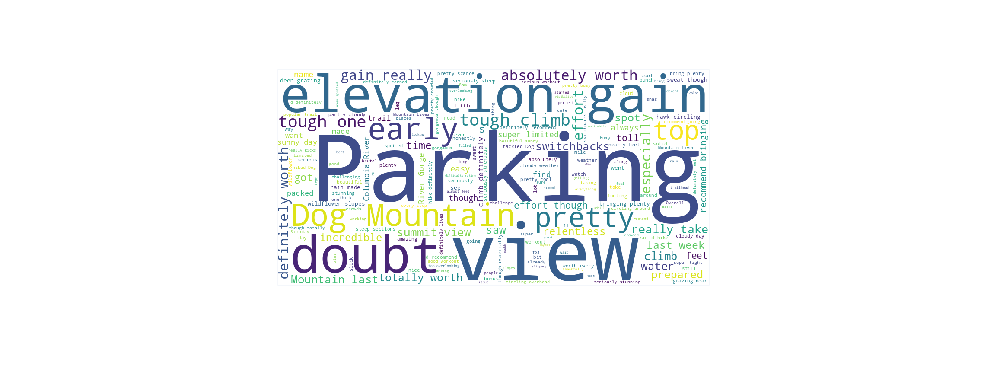

In [34]:
word_cloud_function('Dog Mountain', 4, 5)

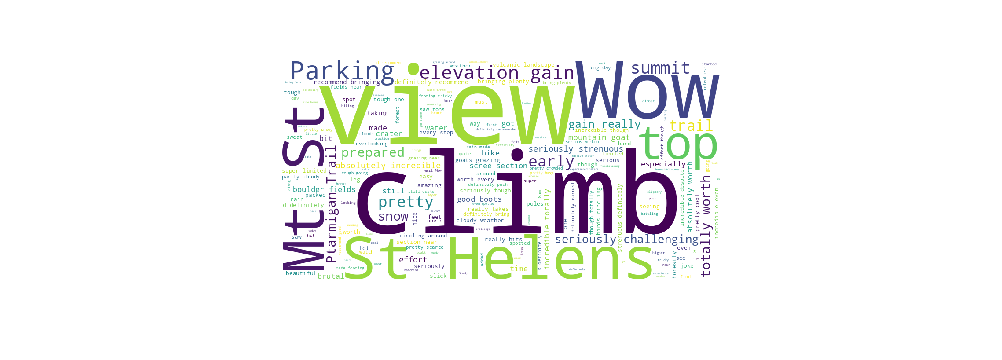

In [35]:
word_cloud_function('Mt. St Helens Summit via Ptarmigan Trail', 4, 5)

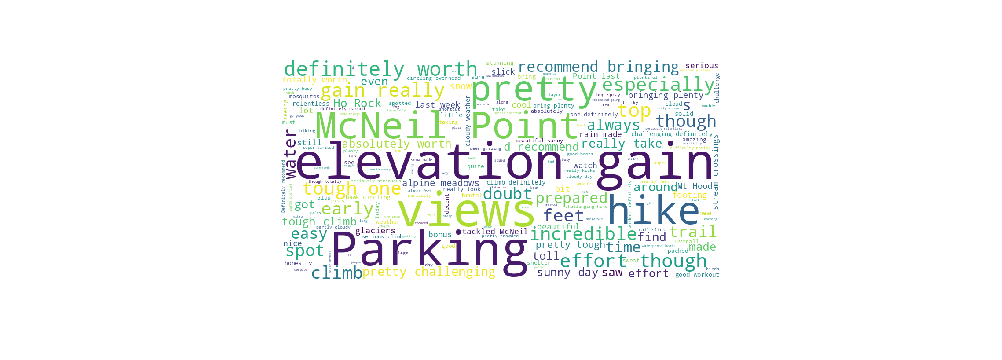

In [36]:
word_cloud_function('McNeil Point', 4, 5)